# LAFC and LPFC characteristics of a complex system

-39.99999999656035
40.00000429951319
-60.0
mean_diff = 159.08243738562103
diff = 349.60237552810594
diff = 359.9999741822829


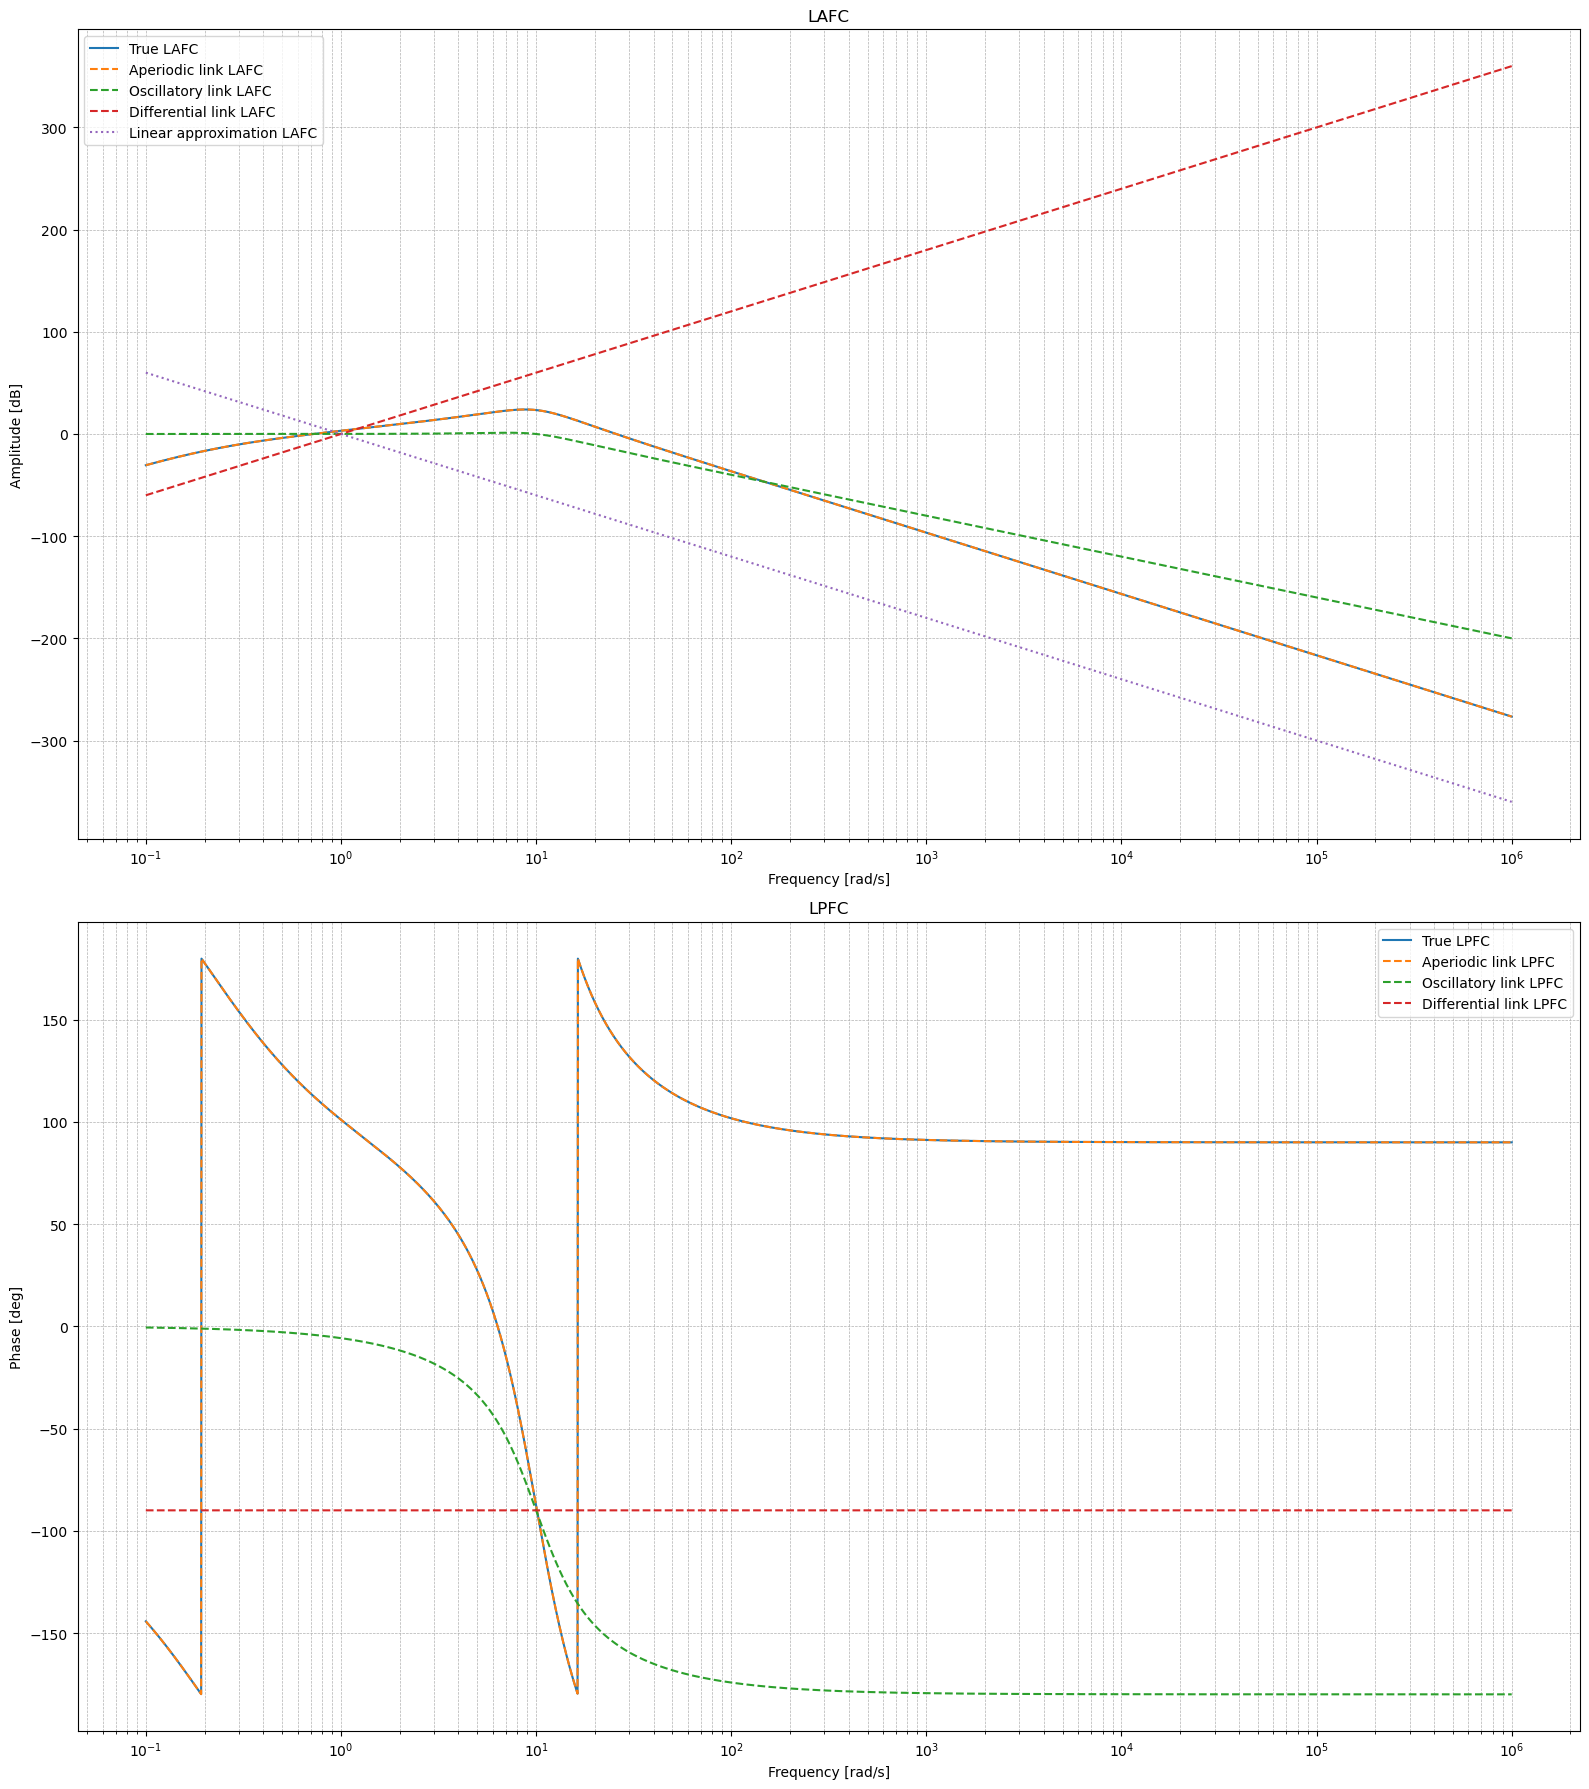

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def calc_W(w):
    numerator = (1j * w)**3
    denominator = 0.027 * (5 * (1j * w) + 1)**2 * (0.01 * (1j * w)**2 + 0.1 * (1j * w) + 1)**2
    return numerator / denominator 

def calc_W1(w):
    return K1 * (T1 * (1j * w) + 1)**2
    
def calc_W2(w):
    return K2 / ((T2 * (1j * w))**2 + 2 * (T2 * XI * (1j * w)) + 1)

def calc_W3(w):
    return (T3 * (1j * w)) ** 3

def calc_AFC(W):
    return np.abs(W)

def calc_PFC(W, deg=True):
    return np.angle(W, deg)

def calc_LAFC(W):
    return 20 * np.log10(calc_AFC(W))
    
w = np.logspace(-1, 6, 4000)
s = 1j * w

# ====== Transfer characteristics calculation ======

# ------ Complex link ------
W = calc_W(w)

# ------ Typical links ------
# Aperiodic link (2nd order)
K1 = 1 / 0.027
T1 = 5
# k / (Ts + 1)^2
# W1 = K1 * (T1 * s + 1)**2
W1 = calc_W1(w)

# ...... Oscillatory link ......
K2 = 1
T2 = 0.1
XI = 0.5
# W(s) = k / ((Ts)^2 + 2*(T*xi*s) + 1)
# W2 = K2 / ((T2 * s)**2 + 2 * (T2 * XI * s) + 1)
W2 = calc_W2(w)

# ...... Differential link (3rd order) ......
# W(s) = Ts
T3 = 1
# W3 = (T3 * s) ** 3
W3 = calc_W3(w)

# ====== LAFC & LPFC calculation ======

# ------ Complex link ------
# lafc_W = 20 * np.log10(np.abs(W))
# lpfc_W = np.angle(W, deg=True)
lafc_W = calc_LAFC(W)
lpfc_W = calc_PFC(W)

# ------ Typical links ------

# ...... Aperiodic link ......
# lafc_W1 = 20 * np.log10(np.abs(W1))
# lpfc_W1 = np.angle(W1, deg=True)
lafc_W1 = calc_LAFC(W)
lpfc_W1 = calc_PFC(W)

# ...... Oscillatory link ......
# lafc_W2 = 20 * np.log10(np.abs(W2))
# lpfc_W2 = np.angle(W2, deg=True)
lafc_W2 = calc_LAFC(W2)
lpfc_W2 = calc_PFC(W2)

# ...... Differential link ......
# lafc_W3 = 20 * np.log10(np.abs(W3))
# lpfc_W3 = np.angle(W3, deg=True)
lafc_W3 = calc_LAFC(W3)
lpfc_W3 = calc_PFC(W3)
 
# ...... Piecewise continuous LAFC approximation ......
dB_per_decade1 = (calc_LAFC(calc_W1(10e3)) - calc_LAFC(calc_W1(10e4)))
dB_per_decade2 = (calc_LAFC(calc_W2(10e3)) - calc_LAFC(calc_W2(10e4)))
dB_per_decade3 = (calc_LAFC(calc_W3(10e3)) - calc_LAFC(calc_W3(10e4)))

print(dB_per_decade1)
print(dB_per_decade2)
print(dB_per_decade3)

lafc_approx = (
    dB_per_decade1 * np.log10(w)
    + dB_per_decade2 * np.log10(w)
    + dB_per_decade3 * np.log10(w)
)


# ...... misc ......

mean_diff = np.mean(np.abs(lafc_approx - W))

print(f'mean_diff = {mean_diff}')
print(f'diff = {np.abs(lafc_approx[-100] - W[-100])}')
print(f'diff = {np.abs(lafc_approx[-1] - W[-1])}')

# ====== Graph plots ======
plt.figure(figsize=(16, 18))

# ------ LAFC ------
plt.subplot(2, 1, 1)
plt.semilogx(w, lafc_W,            label="True LAFC")
plt.semilogx(w, lafc_W1,     "--", label="Aperiodic link LAFC")
plt.semilogx(w, lafc_W2,     "--", label="Oscillatory link LAFC")
plt.semilogx(w, lafc_W3,     "--", label="Differential link LAFC")
plt.semilogx(w, lafc_approx, ":",  label="Linear approximation LAFC")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.title("LAFC")
plt.xlabel("Frequency [rad/s]")
plt.ylabel("Amplitude [dB]")

# ------ LPFC ------
plt.subplot(2, 1, 2)
plt.semilogx(w, lpfc_W,        label="True LPFC")
plt.semilogx(w, lpfc_W1, "--", label="Aperiodic link LPFC")
plt.semilogx(w, lpfc_W2, "--", label="Oscillatory link LPFC")
plt.semilogx(w, lpfc_W3, "--", label="Differential link LPFC")

plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

plt.title("LPFC")
plt.xlabel("Frequency [rad/s]")
plt.ylabel("Phase [deg]")

plt.tight_layout()
plt.show()


[ 59.89843087  59.89652615  59.89264547  59.88861965  59.88444331
  59.88011084  59.87561644  59.8709541   59.86611759  59.86110045
  59.85589597  59.85049721  59.84489698  59.83908782  59.833062
  59.82681151  59.82032805  59.813603    59.80662747  59.79939221
  59.79188764  59.78410387  59.77603061  59.76765722  59.75897268
  59.74996557  59.74062406  59.73093592  59.72088845  59.71046852
  59.69966254  59.68845642  59.67683559  59.66478495  59.6522889
  59.63933127  59.62589532  59.61196375  59.59751865  59.58254149
  59.5670131   59.55091365  59.53422265  59.51691888  59.49898043
  59.48038464  59.46110807  59.44112653  59.42041498  59.39894759
  59.37669765  59.35363758  59.32973891  59.30497224  59.27930721
  59.25271249  59.22515578  59.19660371  59.16702191  59.13637491
  59.10462615  59.07173795  59.0376715   59.0023868   58.96584267
  58.92799671  58.88880529  58.84822352  58.80620522  58.76270292
  58.71766783  58.67104983  58.62279744  58.57285781  58.52117671
  58.46769853

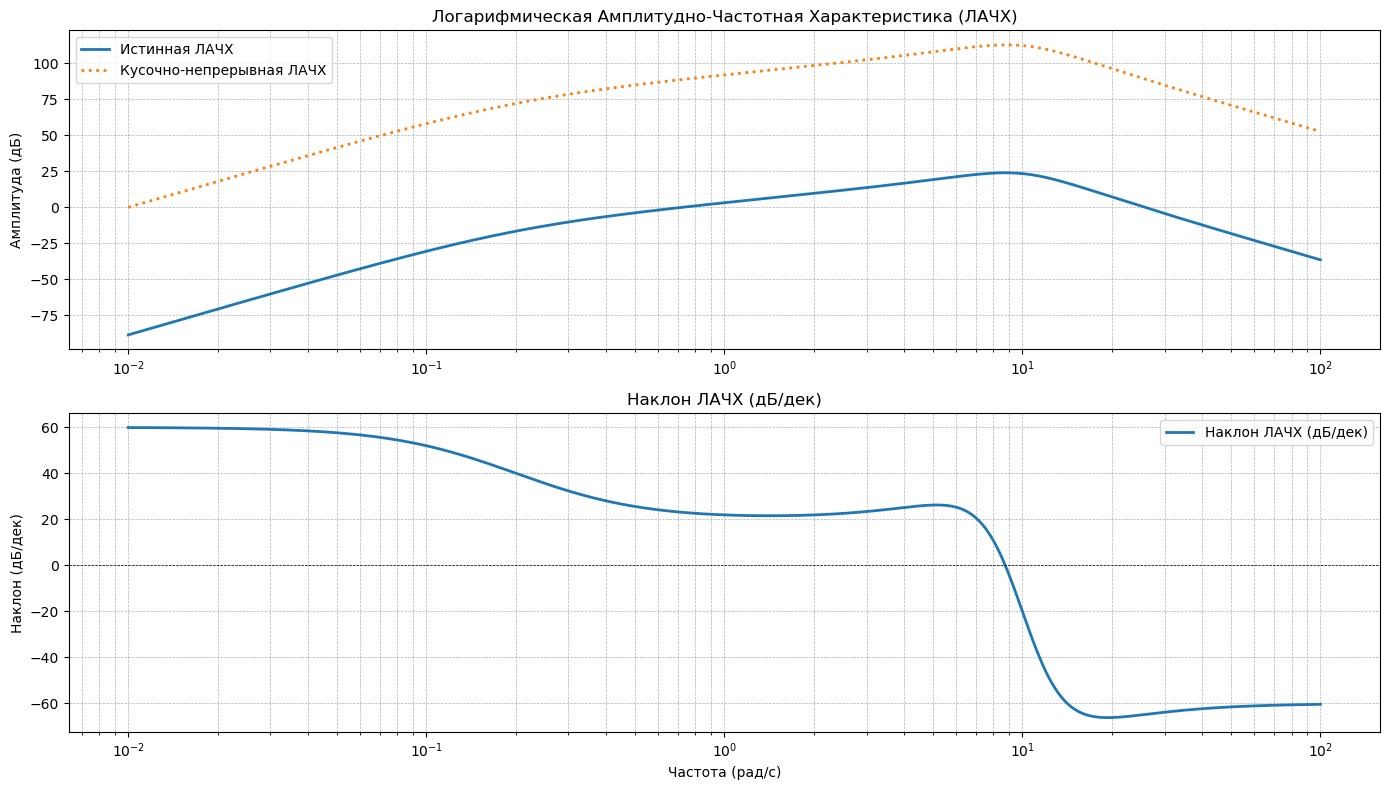

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Задаём частотный диапазон
w = np.logspace(-2, 2, 500)  # от 0.01 до 100 рад/с
s = 1j * w  # оператор Лапласа (p = jω)

# Исходная передаточная функция
numerator = s**3
denominator = 0.027 * (5 * s + 1)**2 * (0.01 * s**2 + 0.1 * s + 1)**2
W = numerator / denominator

# Истинная ЛАЧХ
mag_W = 20 * np.log10(np.abs(W))  # Амплитудно-частотная характеристика (дБ)

# Автоматический расчёт наклонов (дБ/дек)
# Логарифмическое изменение частоты
log_w = np.log10(w)

# Вычисляем наклоны как разность амплитуды на соседних частотах
dB_per_decade = np.gradient(mag_W, log_w)
print(dB_per_decade)
# Кусочно-непрерывная аппроксимация ЛАЧХ
approx_mag = np.zeros_like(w)
current_level = mag_W[0]  # начальное значение ЛАЧХ
for i in range(1, len(w)):
    approx_mag[i] = approx_mag[i - 1] + dB_per_decade[i - 1] * (log_w[i] - log_w[i - 1])

# Построение графиков
plt.figure(figsize=(14, 8))

# ЛАЧХ
plt.subplot(2, 1, 1)
plt.semilogx(w, mag_W, label="Истинная ЛАЧХ", linewidth=2)
plt.semilogx(w, approx_mag, ":", label="Кусочно-непрерывная ЛАЧХ", linewidth=2)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.title("Логарифмическая Амплитудно-Частотная Характеристика (ЛАЧХ)")
plt.ylabel("Амплитуда (дБ)")

# Наклоны ЛАЧХ
plt.subplot(2, 1, 2)
plt.semilogx(w, dB_per_decade, label="Наклон ЛАЧХ (дБ/дек)", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=0.5)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.title("Наклон ЛАЧХ (дБ/дек)")
plt.xlabel("Частота (рад/с)")
plt.ylabel("Наклон (дБ/дек)")

plt.tight_layout()
plt.show()
